In [ ]:
import math
import random

def load_tsp(filename: str) -> list:
    """Function that loads data from the .tsp files based on the formatation prerequisites

    Args:
        filename (str): _description_

    Returns:
        list: _description_
    """
    coords = []
    with open(filename) as f:
        for line in f:
            if line.strip() == 'NODE_COORD_SECTION':
                break
        for line in f:
            if line.strip() == 'EOF':
                break
            parts = line.split()
            x, y = float(parts[1]), float(parts[2])
            coords.append((x, y))
    return coords

In [ ]:
def euclidean_distance(a: tuple, b: tuple) -> float:
    """Function that computes the euclidean distance between
        2 points given as coordinates

    Args:
        a (tuple): (a.x, a.y)
        b (tuple): (b.x, b.y)

    Returns:
        float: the distance
    """
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def tour_length(tour, dist ):
    """Function that computes the tour length based on some precomputed weights

    Args:
        tour (_type_): The tour beeing testes
        dist (_type_): The precomputed distances

    Returns:
        length (float) : The result
    """
    n = len(tour)
    return sum(dist[tour[i]][tour[(i + 1) % n]] for i in range(n))

In [55]:
def greedy_tsp(filename: str) -> tuple:
    """A solution for the tsp problem using a greedy method.
    The method consists of starting at a random node and always selecting the closest unvisited node
    

    Args:
        filename (str): _description_

    Returns:
        tuple: _description_
    """
    
    coords = load_tsp(filename)
    n = len(coords)
    start = random.randint(0,n-1)

    tour = [start]
    available = set(range(n))
    available.remove(start)
    current = start
    
    dists = [[euclidean_distance(coords[i], coords[j]) 
         for j in range(n)] 
         for i in range(n)]

    while available:
        nearest = None
        nearest_dist = float('inf')

        for node in available:
            dist = euclidean_distance(coords[current], coords[node])
            if dist < nearest_dist:
                nearest_dist = dist
                nearest = node        
        tour.append(nearest)
        available.remove(nearest)
        current = nearest

    length = tour_length(tour, dists)
    return tour, length, dists

In [82]:
from collections import deque

def tabu_for_tsp(filename: str, iterations: int, max_tries: int = 4, sample_size: int = 100):
    """ Tabu search implemnted specifically for the tsp problem.
    We use the 2-opt neighbour and for better efficieny we have a sample size for the amount of
    neighbour distances checked.

    Args:
        filename (str): input file
        iterations (int): number of iterations over the finding best neighbiur
        max_tries (int, optional): number of tries we restart from random tour or random greedy
        sample_size (int, optional): number of neighbour distances beeing checked for efficiency

    Returns:
        best_length (float) : The final result for the TSP
    """
    coords = load_tsp(filename)
    n = len(coords)
    tabu_tenure = int(math.sqrt(n))
    tabu_tenure = 3*n

    _, _, dists = greedy_tsp(filename)

    global_best = None
    global_best_length = float('inf')

    for try_ in range(max_tries):

        c, length, _ = greedy_tsp(filename)
        
        # c = list(range(n))
        # random.shuffle(c)
        # length = tour_length(c, dists)      
        
        best = c.copy()
        best_length = tour_length(best, dists)

        M = deque(maxlen=tabu_tenure)

        for iteration in range(iterations):
            x, x_length, x_move = None, float('inf'), (-1, -1)

            T = set()
            while len(T) < sample_size:
                i = random.randint(0, n - 2)
                j = random.randint(i + 1, n - 1)
                T.add((i, j))

            for i, j in T:
                neighbor = c.copy()
                neighbor[i:j+1] = neighbor[i:j+1][::-1]
                neighbor_length = tour_length(neighbor, dists)

                is_tabu = (i, j) in M or (j, i) in M

                if not is_tabu or neighbor_length < best_length:
                    if neighbor_length < x_length:
                        x, x_length, x_move = neighbor.copy(), neighbor_length, (i, j)

            if x is None:
                continue

            M.append(x_move)
            c = x

            if x_length < best_length:
                best = x.copy()
                best_length = x_length

        if best_length < global_best_length:
            global_best = best.copy()
            global_best_length = best_length
            
    return global_best_length

In [77]:
# 26051. for Rwanda
# 7542 for Berlin
print(tabu_for_tsp('../Lab3Assigment3/berlin52.tsp', iterations=1000, sample_size=200))

7544.36590190409


In [ ]:
print(tabu_for_tsp('../Lab3Assigment3/rw1621.tsp', iterations=10, sample_size=50000))

32106.544247568883


In [ ]:
import matplotlib.pyplot as plt

def generate_report(input : str, output : str) :
    """Generates a full report and a plot of the results

    Args:
        input (str): _description_
        output (str): _description_
    """
    
    values_for_iterations = [100, 250, 500, 1000, 1250, 1500, 2000, 2250]
    results_for_iterations = []
    with open(output, 'a') as f :
        f.write(f"\n**Report begining for berlin52 instance**\n")
    for value in values_for_iterations :
        result = tabu_for_tsp('../Lab3Assigment3/berlin52.tsp', iterations=value, sample_size=200)
        results_for_iterations.append(result)
        with open(output, "a") as f:
            f.write(f"For iterations={value}, max_tries={4}, sample_size for neighbour amount=200 we got result = {result}\n")
            
    plt.plot(values_for_iterations, results_for_iterations, marker='o')
    plt.title("Tabu search chart for berlin52")
    plt.xlabel("N-value for the number of iterations over the neighbours")
    plt.ylabel("Best path found")
    plt.grid(True)
    plt.show()


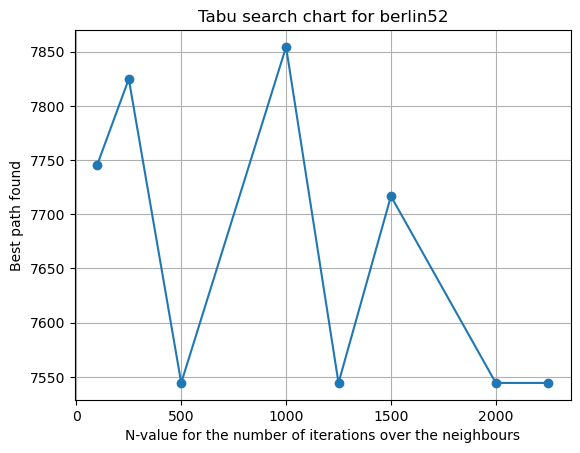

In [ ]:
# Here is for random start for berlin52
generate_report('../Lab3Assigment3/berlin52.tsp', 'results_for_berlin52.txt')

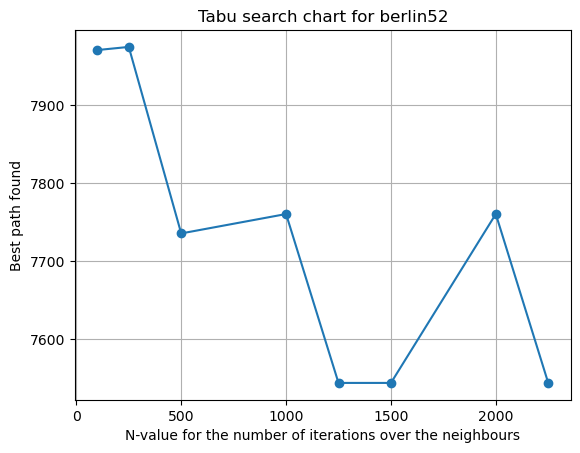

In [ ]:
# Here is for greedy start for berlin52
generate_report('../Lab3Assigment3/berlin52.tsp', 'results_for_berlin52.txt')

In [ ]:
# Report generated for rw1621
generate_report('../Lab3Assigment3/rw1621.tsp', 'results_for_rw1621')